# The Frugal Parameterization for Bayesian Causal Inference in PyMC

In this notebook we provide an introduction to the frugal parameterization for Bayesian causal inference. We illustrate the concepts with a simple example using synthetic data and an explicit [`PyMC`](https://www.pymc.io/) implementation.

The authors of the frugal parameterization (Evans & Didelez, 2024) have implemented an [`R`](https://www.r-project.org/) package called [`causl`](https://github.com/rje42/causl) that allows you to specify, simulate from and fit causal models using the frugal parameterization.

## Motivation

Bayesian causal inference typically proceeds as follows:

1. **Specify a full generative model** for the joint distribution of treatment, outcome, and confounders using conditional distributions.
2. **Fit the model** using MCMC or variational inference.
3. **Derive the causal estimand** (e.g., the Average Treatment Effect) as a function of the posterior over model parameters.

For example, consider a simple setting with a confounder $Z$, a binary treatment $X$, and a continuous outcome $Y$. The causal graph is:



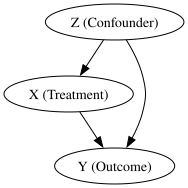

In [1]:
import graphviz as gr

g = gr.Digraph(comment="Causal Graph")

g.node("Z", "Z (Confounder)")
g.node("X", "X (Treatment)")
g.node("Y", "Y (Outcome)")

g.edge("Z", "X")
g.edge("Z", "Y")
g.edge("X", "Y")

g

The standard Bayesian model would be:

$$
Z \sim \text{Normal}(0, 1)
$$
$$
X \mid Z \sim \text{Bernoulli}\!\left(\text{logit}^{-1}(\alpha_0 + \alpha_1 Z)\right)
$$
$$
Y \mid X, Z \sim \text{Normal}(\beta_0 + \beta_1 X + \beta_2 Z, \, \sigma^2)
$$

The **Average Treatment Effect** (ATE) is:

$$
\text{ATE} = \mathbb{E}[Y \mid \text{do}(X=1)] - \mathbb{E}[Y \mid \text{do}(X=0)]
$$

In this linear model, the ATE happens to equal $\beta_1$. But this is a **coincidence of the linear specification**. In general, with non-linear models, interactions, or non-Gaussian outcomes, the ATE is a complex function of all model parameters.

This creates three practical problems:

**Problem 1: You can't put a prior directly on the causal effect.** Your priors go on regression coefficients ($\beta_0, \beta_1, \beta_2$), not on the quantity you actually care about. If a domain expert says *"we believe this treatment reduces the outcome by 10–20%"*, translating that into priors on regression coefficients is awkward and indirect, especially in non-linear models.

**Problem 2: Simulation with known causal effects is difficult.** If you want to generate synthetic data where the *true* ATE has a specific value (for benchmarking, power analysis, or sensitivity analysis), you can't just set it. You have to reverse-engineer which conditional parameters would produce the desired marginal causal effect. As Havercroft & Didelez (2012) showed, this is surprisingly hard even in seemingly simple longitudinal settings.

**Problem 3: Likelihood-based inference on marginal causal quantities is indirect.** The causal estimand is a marginal quantity of the *interventional* distribution, but the data comes from the *observational* distribution. You fit the full conditional model and then post-process the posterior. This is inefficient and can be numerically unstable.   


## The Frugal Parameterization

### Core idea

Evans & Didelez (2024) propose to **flip the parameterization**: instead of starting with conditional distributions and deriving the causal effect, start with the causal effect and build the rest of the joint distribution around it.

The joint observational distribution $P(Z, X, Y)$ is decomposed into three **variation-independent** components:

| Component | What it represents | What you specify |
|---|---|---|
| **(a) "The past"** | $P(Z, X)$ | Confounder distribution + propensity score |
| **(b) Causal margin** | $P^*(Y \mid \text{do}(X))$ | Interventional outcome distribution |
| **(c) Dependence** | Association between $Y$ and $Z$ beyond $X$ | Copula or odds ratio |

The term **"frugal"** refers to the fact that this parameterization uses exactly the parameters needed, no more, no less, with the causal quantity of interest at the center.
More precisely, following Definition 2.1 in Evans & Didelez (2024), a parameterization of the joint distribution $P(Z, X, Y)$ is *frugal* with respect to the causal kernel $P^*(Y \mid X)$ if it consists of three components

1. A parameterization of the past $P(Z, X)$
2. The interventional kernel $P^*(Y \mid X)$
3. A conditional association measure $\varphi^*_{YZ \mid X}$

that are jointly sufficient to determine the full observational distribution and are **variation independent** we will explain what this means below) of each other. There is nothing redundant (each component controls a distinct aspect of the joint distribution) and nothing missing (the three together fully determine $P(Z, X, Y)$).

In the standard parameterization, causal and non-causal information is tangled: $\beta_1$ encodes the causal effect, but $\beta_2$ and $\sigma$ jointly encode both the confounding structure and the residual variation in a way that is not separable. The frugal parameterization disentangles these by placing the causal effect $\delta$ in its own component (b), the confounding association $\rho$ in component (c), and the treatment assignment mechanism in component (a).

### Why "variation independent"?

**Variation independence** means that the parameter space of the full model is the Cartesian product of the parameter spaces of the three components. In other words, any value of the causal effect $\delta$ is compatible with any value of the copula correlation $\rho$ and any values of the propensity parameters $(\alpha_0, \alpha_1)$. No choice of one component restricts the feasible values of the others.

To see why this is non-trivial, consider the standard parameterization. Suppose you know $\sigma = 1$ and $\beta_2 = 0.7$. Then, as we will see below, the implied causal standard deviation and copula correlation are constrained by $\sigma_c^2(1 - \rho^2) = 1$ and $\rho \cdot \sigma_c = 0.7$, so $\sigma_c$ and $\rho$ cannot vary freely, they are linked through these two equations. Changing one forces the other to change. In the frugal parameterization, $\sigma_c$ and $\rho$ are free parameters by construction; their relationship to the observational quantities $(\sigma, \beta_2)$ is a consequence, not a constraint.

**The Bayesian consequence.** Because the parameter spaces factor as a Cartesian product, a product prior $p(\theta_{\text{past}}) \times p(\theta_{\text{causal}}) \times p(\theta_{\text{dependence}})$ is always a valid joint prior — there are no hidden constraints that could make certain prior combinations inadmissible. This is exactly what Steiner & Steel (2024) call **prior independence**: you can put an informative prior on the causal effect $\delta$ (e.g., from a pilot experiment) without that prior implicitly constraining the propensity model or the dependence structure, and vice versa.

### Background: What is a copula?

When building a joint distribution of two (or more) random variables, you need to specify two things: (a) the *marginal* distributions (what each variable looks like on its own) and (b) the *dependence structure* (how they co-vary). A **copula** is a mathematical device that handles (b) separately from (a), letting you mix and match different marginals with different dependence structures.

**Sklar's theorem** (1959) makes this precise: any joint distribution $F(y, z)$ of continuous random variables can be written as

$$
F(y, z) = C\!\left(F_Y(y), \, F_Z(z)\right)
$$

where $F_Y$ and $F_Z$ are the marginal CDFs and $C: [0,1]^2 \to [0,1]$ is a copula function. Conversely, for *any* choice of marginals $F_Y, F_Z$ and *any* copula $C$, this formula produces a valid joint distribution. The copula $C$ captures *all* of the dependence structure, completely separated from the marginals.

**The Gaussian copula** is constructed as follows: (i) transform each variable to its uniform quantile via the probability integral transform: $u = F_Y(y)$, $v = F_Z(z)$; (ii) map these uniforms to standard normals: $\tilde{y} = \Phi^{-1}(u)$, $\tilde{z} = \Phi^{-1}(v)$; (iii) model the dependence between $\tilde{y}$ and $\tilde{z}$ as a bivariate normal with correlation $\rho$. When the marginals are themselves Gaussian, steps (i)–(ii) reduce to standardization, and the Gaussian copula with correlation $\rho$ produces a bivariate normal. This is why, in the Gaussian-Gaussian case used later in this post to illustrate these concepts, the joint interventional distribution of $(Y^*, Z)$ is simply a bivariate normal.

**Code References:** The `PyMC` documentation has a great tutorial on copulas: [Bayesian copula estimation: Describing correlated joint distributions](https://www.pymc.io/projects/examples/en/latest/howto/copula-estimation.html). Additionally, Thomas Wiecki has a great blog post on copulas: [An intuitive, visual guide to copulas](https://twiecki.io/blog/2018/05/03/copulas/).

**Why copulas matter for the frugal parameterization:** In the frugal decomposition, the dependence component (c) needs to "couple" the interventional outcome $Y^*$ with the confounder $Z$ while keeping the causal margin (b) and the past (a) untouched. The copula is the natural tool for this: you can specify the causal margin $P^*(Y \mid \text{do}(X))$ and the confounder distribution $P(Z)$ as marginals, then use a copula to model their dependence, all independently. Proposition 2.5 in Evans & Didelez (2024) confirms that the triple (marginals $P_{Z,X}$, interventional kernel $P^*_{Y \mid X}$, conditional copula $C_{YZ \mid X}$) is always a frugal parameterization.


### The Gaussian copula case

For continuous outcomes with Gaussian margins, the dependence component (c) can be parameterized using a **Gaussian copula** with correlation parameter $\rho$.

Concretely, let:
- $\mu(x) = \mu_0 + \delta \cdot x$ be the mean of $Y$ under intervention $\text{do}(X=x)$
- $\sigma_c$ be the standard deviation of $Y$ under intervention
- $\rho$ be the Gaussian copula correlation between $Y$ and $Z$ given $X$

Then the **observational** conditional distribution $Y \mid X, Z$ has a closed-form expression:

$$
Y \mid X=x, Z=z \;\sim\; \text{Normal}\!\left(
  \underbrace{(\mu_0 + \delta \cdot x)}_{\text{causal margin mean}}
  + \underbrace{\rho \cdot \sigma_c \cdot z}_{\text{copula adjustment}},
  \;\; \sigma_c^2 (1 - \rho^2)
\right)
$$

where we have assumed $Z$ is standardized ($\mu_Z = 0, \sigma_Z = 1$).

**Key observation:** The parameter $\delta$ is the ATE. It is now a *direct* model parameter, not a derived quantity. We can put a prior on it: $\delta \sim \text{Normal}(0, 2)$ (weakly-informative) or $\delta \sim \text{Normal}(0.5, 0.1)$ (informative, from a pilot experiment).

The copula correlation $\rho$ absorbs the confounding association between $Z$ and $Y$ that is *not* mediated by the treatment $X$. It plays the role that $\beta_2$ plays in the standard regression, but it is parameterized in terms of the copula rather than a regression coefficient.

After this theoretical discussion, we now implement both parameterizations in PyMC and compare them on synthetic data.

## Prepare Notebook

In [2]:
from typing import NamedTuple

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import seaborn as sns
from pymc import do

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

In [3]:
seed: int = 41
rng: np.random.Generator = np.random.default_rng(seed=seed)

We generate data from a simple causal model:

- A confounder $Z \sim \text{Normal}(0, 1)$
- A treatment $X \mid Z \sim \text{Bernoulli}(\text{logit}^{-1}(-0.5 + 0.8 Z))$
- An outcome $Y \mid X, Z \sim \text{Normal}(1.0 + 0.5 X + 0.7 Z, \, 1.0)$

The **true ATE** is $\delta = 0.5$.

In [4]:
class SimParams(NamedTuple):
    """Simulation parameters for the causal model."""

    n_obs: int
    alpha_0: float
    alpha_1: float
    beta_0: float
    beta_1: float
    beta_2: float
    sigma_y: float

    @property
    def true_ate(self) -> float:
        return self.beta_1


sim_params = SimParams(
    n_obs=500,
    alpha_0=-0.5,
    alpha_1=0.8,
    beta_0=1.0,
    beta_1=0.5,
    beta_2=0.7,
    sigma_y=1.0,
)

We now generate the synthetic data from a generative model.

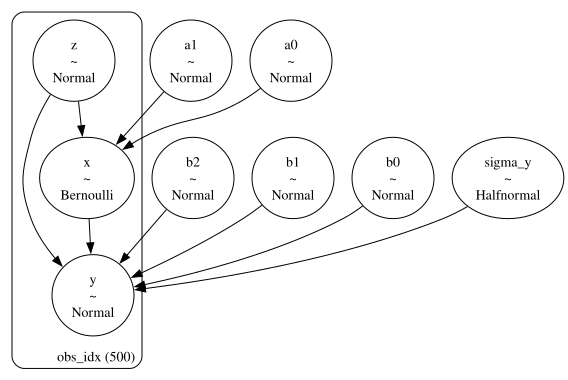

In [5]:
coords = {"obs_idx": np.arange(sim_params.n_obs)}

with pm.Model(coords=coords) as generative_model:
    _z = pm.Normal("z", 0, 1, dims="obs_idx")

    _a0 = pm.Normal("a0", 0, 2)
    _a1 = pm.Normal("a1", 0, 2)
    _b0 = pm.Normal("b0", 0, 2)
    _b1 = pm.Normal("b1", 0, 2)
    _b2 = pm.Normal("b2", 0, 2)
    _sigma_y = pm.HalfNormal("sigma_y", 1)

    _x = pm.Bernoulli("x", p=pm.math.invlogit(_a0 + _a1 * _z), dims="obs_idx")

    _mu_y = _b0 + _b1 * _x + _b2 * _z
    pm.Normal("y", mu=_mu_y, sigma=_sigma_y, dims="obs_idx")

pm.model_to_graphviz(generative_model)

We condition the generative model on the true parameters:

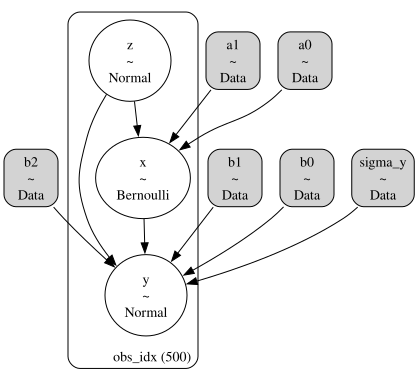

In [6]:
conditioned_generative_model = do(
    generative_model,
    {
        "a0": sim_params.alpha_0,
        "a1": sim_params.alpha_1,
        "b0": sim_params.beta_0,
        "b1": sim_params.beta_1,
        "b2": sim_params.beta_2,
        "sigma_y": sim_params.sigma_y,
    },
)

pm.model_to_graphviz(conditioned_generative_model)

We now sample the prior predictive distribution to extract one sample which will be our synthetic dataset.

In [7]:
with conditioned_generative_model:
    prior_samples = pm.sample_prior_predictive(draws=1, random_seed=rng)

z_obs = prior_samples["prior"]["z"].sel(chain=0, draw=0).to_numpy()
x_obs = prior_samples["prior"]["x"].sel(chain=0, draw=0).to_numpy()
y_obs = prior_samples["prior"]["y"].sel(chain=0, draw=0).to_numpy()

Sampling: [x, y, z]


Let's visualize the observed data:

/Users/juanitorduz/Documents/website_projects/.pixi/envs/default/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


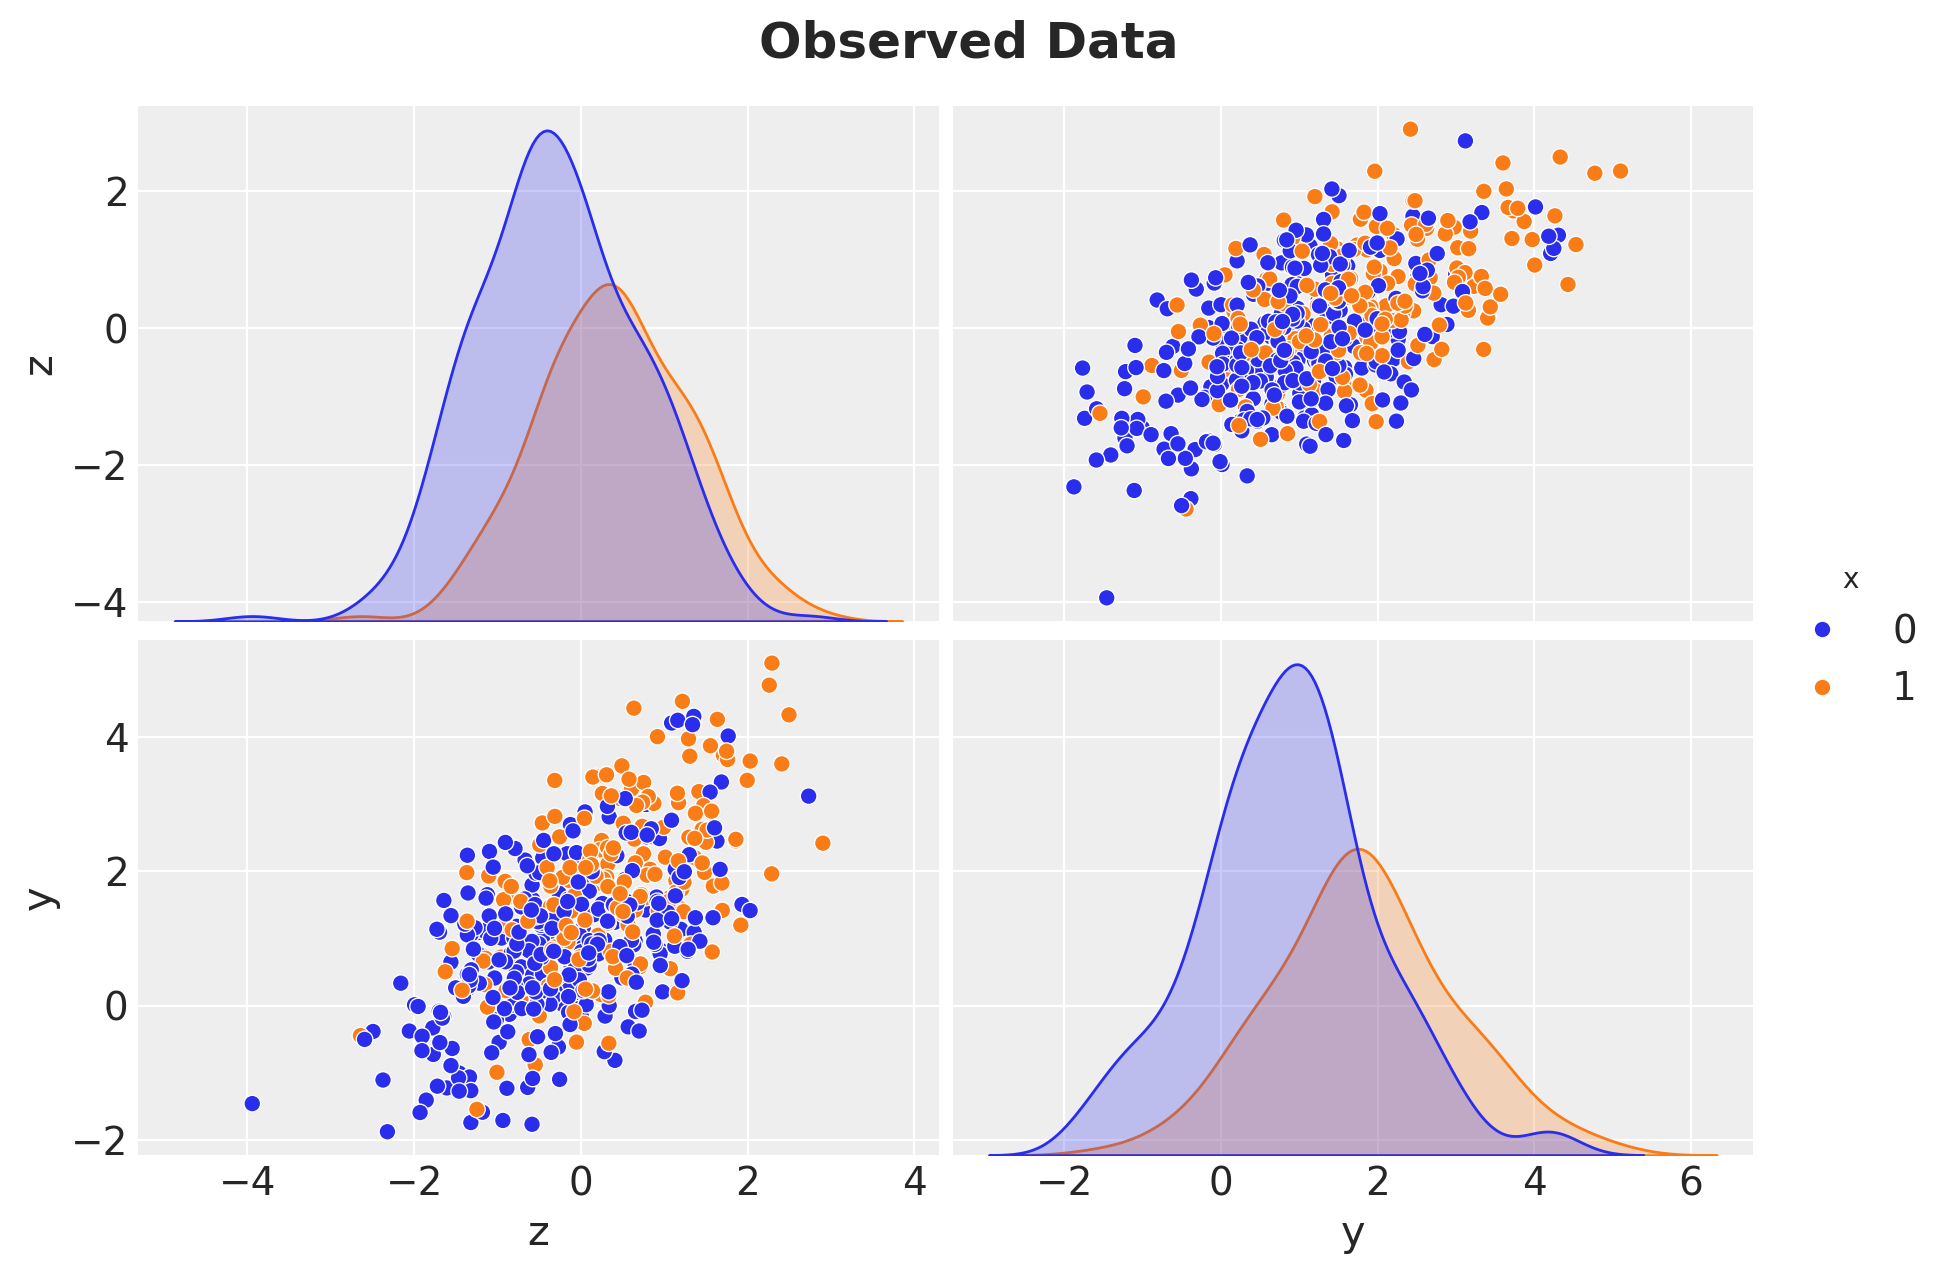

In [8]:
g = sns.pairplot(
    pd.DataFrame(
        {
            "z": z_obs,
            "x": x_obs,
            "y": y_obs,
        }
    ),
    hue="x",
    height=3,
    aspect=1.5,
)
g.figure.suptitle("Observed Data", fontsize=18, fontweight="bold", y=1.05);

## Standard parameterization

This is the conventional Bayesian regression approach. We specify the full conditional model and put priors on the regression coefficients.

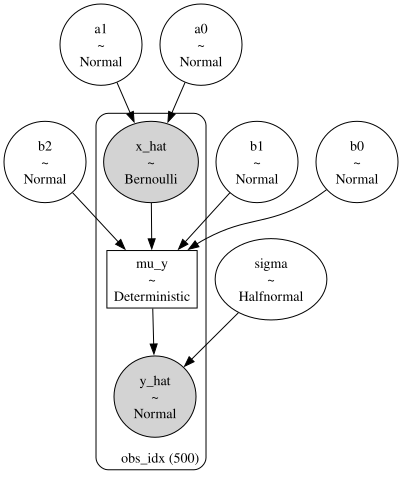

In [9]:
with pm.Model(coords=coords) as standard_model:
    a0 = pm.Normal("a0", 0, 2)
    a1 = pm.Normal("a1", 0, 2)
    b0 = pm.Normal("b0", 0, 2)
    b1 = pm.Normal("b1", 0, 2)  # ATE = b1 (only in the linear case!)
    b2 = pm.Normal("b2", 0, 2)
    sigma = pm.HalfNormal("sigma", 2)

    x_hat = pm.Bernoulli(
        "x_hat", p=pm.math.invlogit(a0 + a1 * z_obs), observed=x_obs, dims="obs_idx"
    )

    mu_y = pm.Deterministic("mu_y", b0 + b1 * x_hat + b2 * z_obs, dims="obs_idx")
    pm.Normal("y_hat", mu=mu_y, sigma=sigma, observed=y_obs, dims="obs_idx")


pm.model_to_graphviz(standard_model)

In [10]:
sampler_kwargs = {
    "draws": 2_000,
    "tune": 1_500,
    "chains": 4,
    "random_seed": rng,
}


with standard_model:
    idata_standard = pm.sample(**sampler_kwargs)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a0, a1, b0, b1, b2, sigma]


Output()

Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 1 seconds.


In [11]:
az.summary(idata_standard, var_names=["b0", "b1", "b2", "sigma"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b0,1.041,0.057,0.926,1.141,0.001,0.001,6818.0,5819.0,1.0
b1,0.497,0.093,0.331,0.683,0.001,0.001,6890.0,5825.0,1.0
b2,0.656,0.044,0.573,0.741,0.000,0.000,8921.0,6326.0,1.0
sigma,0.970,0.031,0.914,1.027,0.000,0.000,8890.0,5951.0,1.0


In the standard model, the ATE posterior is simply the posterior of `b1`. Note that this only works because the model is linear. In a non-linear model, we need to use custom transformations of  the posterior parameters, see for example: [ATE Estimation with Logistic Regression](https://juanitorduz.github.io/causal_inference_logistic/).

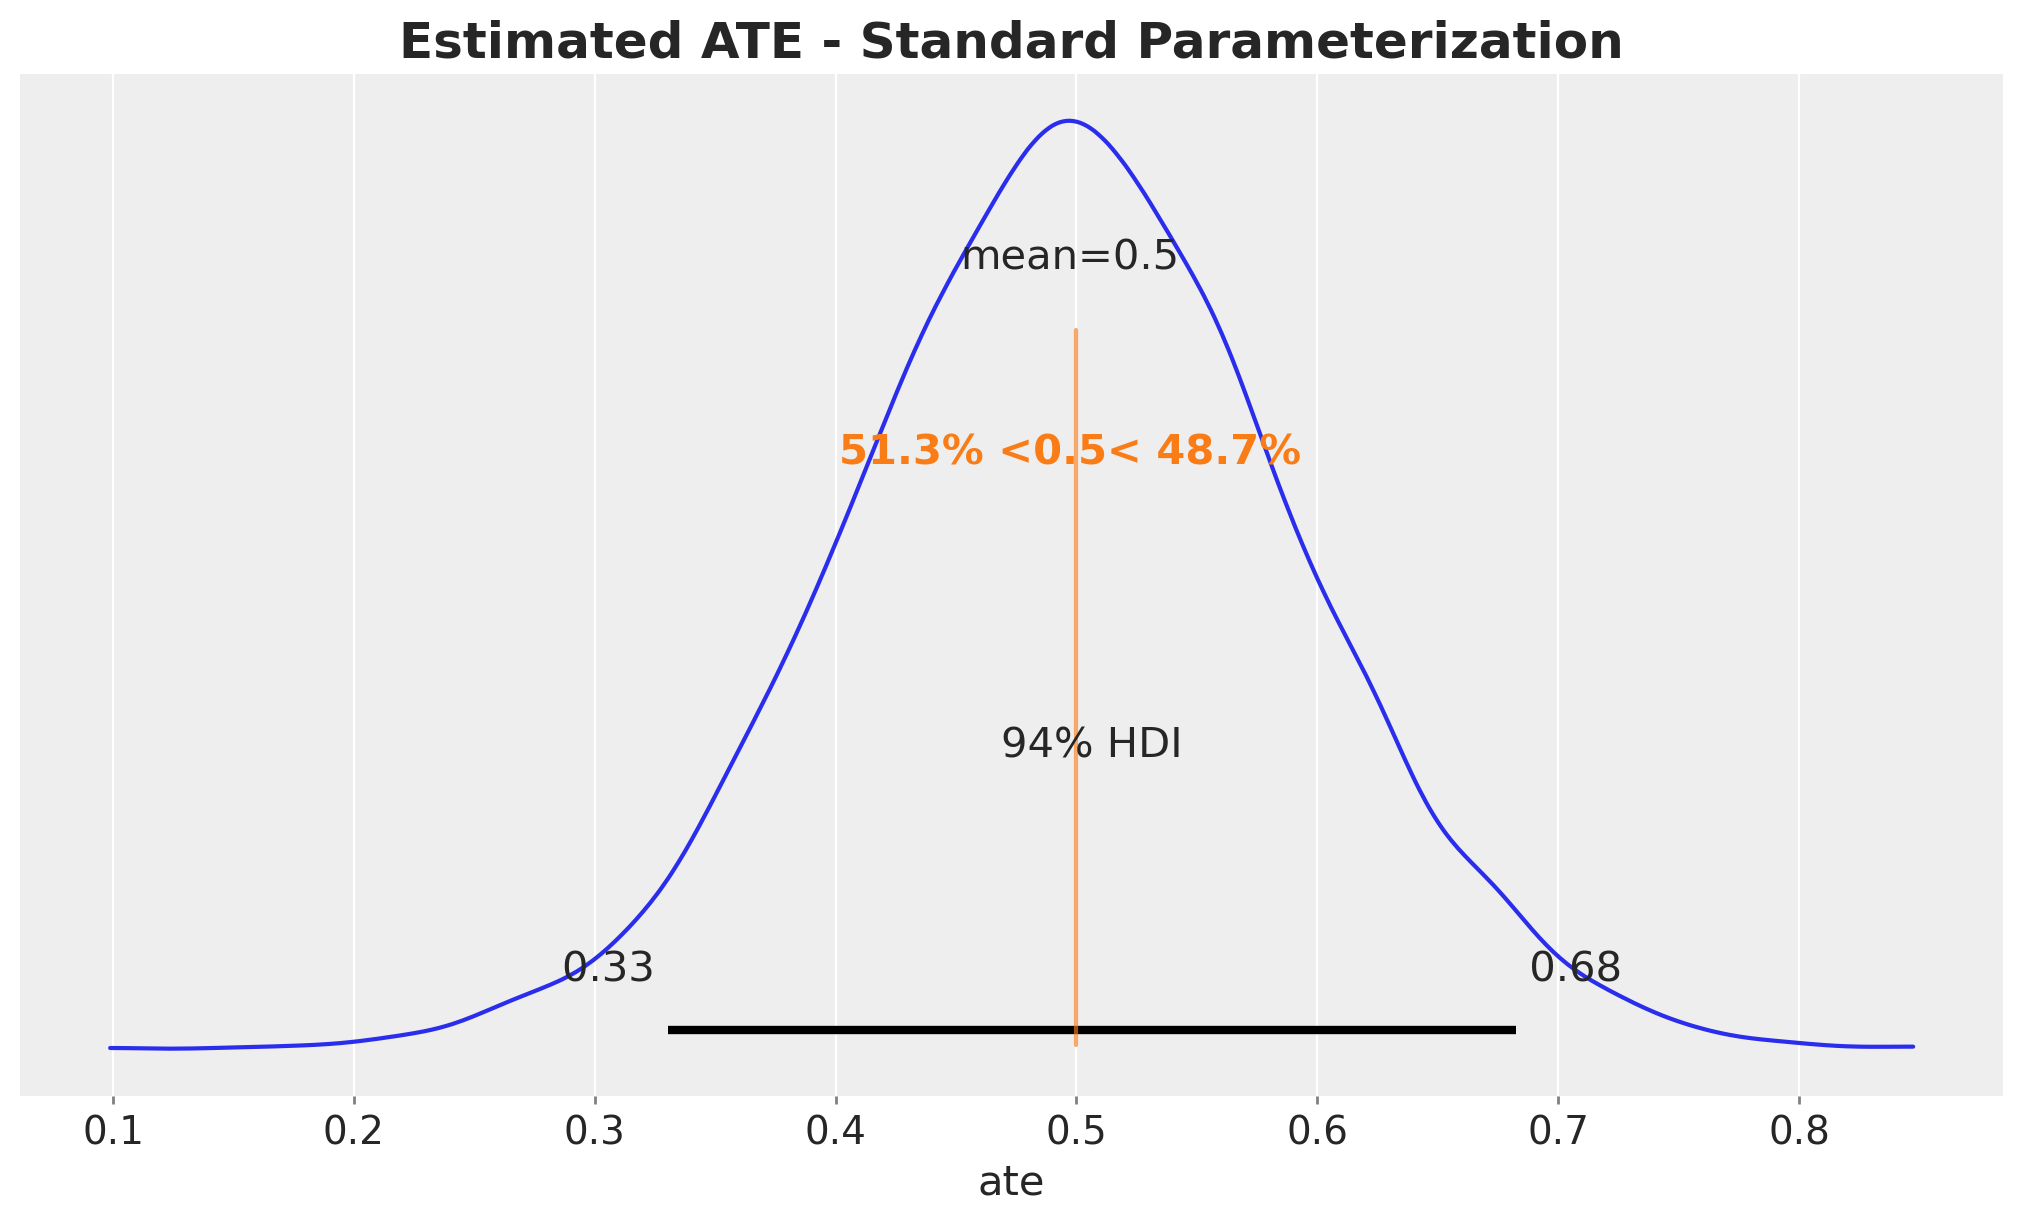

In [12]:
fig, ax = plt.subplots()
az.plot_posterior(idata_standard, var_names=["b1"], ref_val=sim_params.true_ate, ax=ax)
ax.set(xlabel="ate")
ax.set_title(
    "Estimated ATE - Standard Parameterization", fontsize=18, fontweight="bold"
);

We recover the true ATE around $0.5$.

## Frugal parameterization

Now we implement the frugal parameterization. The model has three blocks:

1. **The past** $P(Z, X)$: same propensity model as before.
2. **Causal margin** $P^*(Y \mid \text{do}(X))$: parameterized by $\mu_0$
   (baseline outcome), $\delta$ (ATE), and $\sigma_c$ (causal SD).
3. **Dependence**: Gaussian copula correlation $\rho$ between $Y$ and $Z$.

The observational likelihood is:

$$
Y \mid X=x, Z=z \sim \text{Normal}\!\left(
  (\mu_0 + \delta x) + \rho \sigma_c z, \;\;
  \sigma_c^2 (1 - \rho^2)
\right)
$$

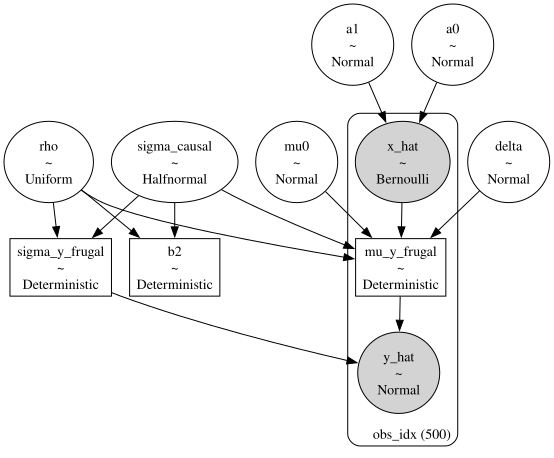

In [13]:
with pm.Model(coords=coords) as frugal_model:
    # --- (a) The past: propensity model P(X|Z) ---
    a0 = pm.Normal("a0", 0, 2)
    a1 = pm.Normal("a1", 0, 2)
    x_hat = pm.Bernoulli(
        "x_hat", p=pm.math.invlogit(a0 + a1 * z_obs), observed=x_obs, dims="obs_idx"
    )

    # --- (b) Causal margin: P*(Y | do(X)) ---
    mu0 = pm.Normal("mu0", 0, 2)  # E[Y | do(X=0)]
    delta = pm.Normal("delta", 0, 2)  # ATE (direct parameter!)
    sigma_causal = pm.HalfNormal("sigma_causal", 1)

    # --- (c) Dependence: Gaussian copula ---
    rho = pm.Uniform("rho", -0.95, 0.95)

    b2 = pm.Deterministic("b2", rho * sigma_causal)

    # --- Observational likelihood ---
    mu_y_frugal = pm.Deterministic(
        "mu_y_frugal", mu0 + delta * x_hat + rho * sigma_causal * z_obs, dims="obs_idx"
    )
    sigma_y_frugal = pm.Deterministic(
        "sigma_y_frugal",
        sigma_causal * pt.sqrt(1 - rho**2),
    )

    pm.Normal(
        "y_hat", mu=mu_y_frugal, sigma=sigma_y_frugal, observed=y_obs, dims="obs_idx"
    )

pm.model_to_graphviz(frugal_model)

In [14]:
with frugal_model:
    idata_frugal = pm.sample(**sampler_kwargs)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a0, a1, mu0, delta, sigma_causal, rho]


Output()

Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 1 seconds.


In [15]:
az.summary(idata_frugal, var_names=["mu0", "delta", "sigma_causal", "rho"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu0,1.039,0.058,0.929,1.147,0.001,0.001,7024.0,6065.0,1.0
delta,0.500,0.094,0.331,0.682,0.001,0.001,6998.0,6378.0,1.0
sigma_causal,1.170,0.036,1.104,1.237,0.000,0.000,8671.0,6013.0,1.0
rho,0.558,0.029,0.502,0.610,0.000,0.000,6748.0,5661.0,1.0


We now plot the posterior of the ATE based on the frugal parameterization.

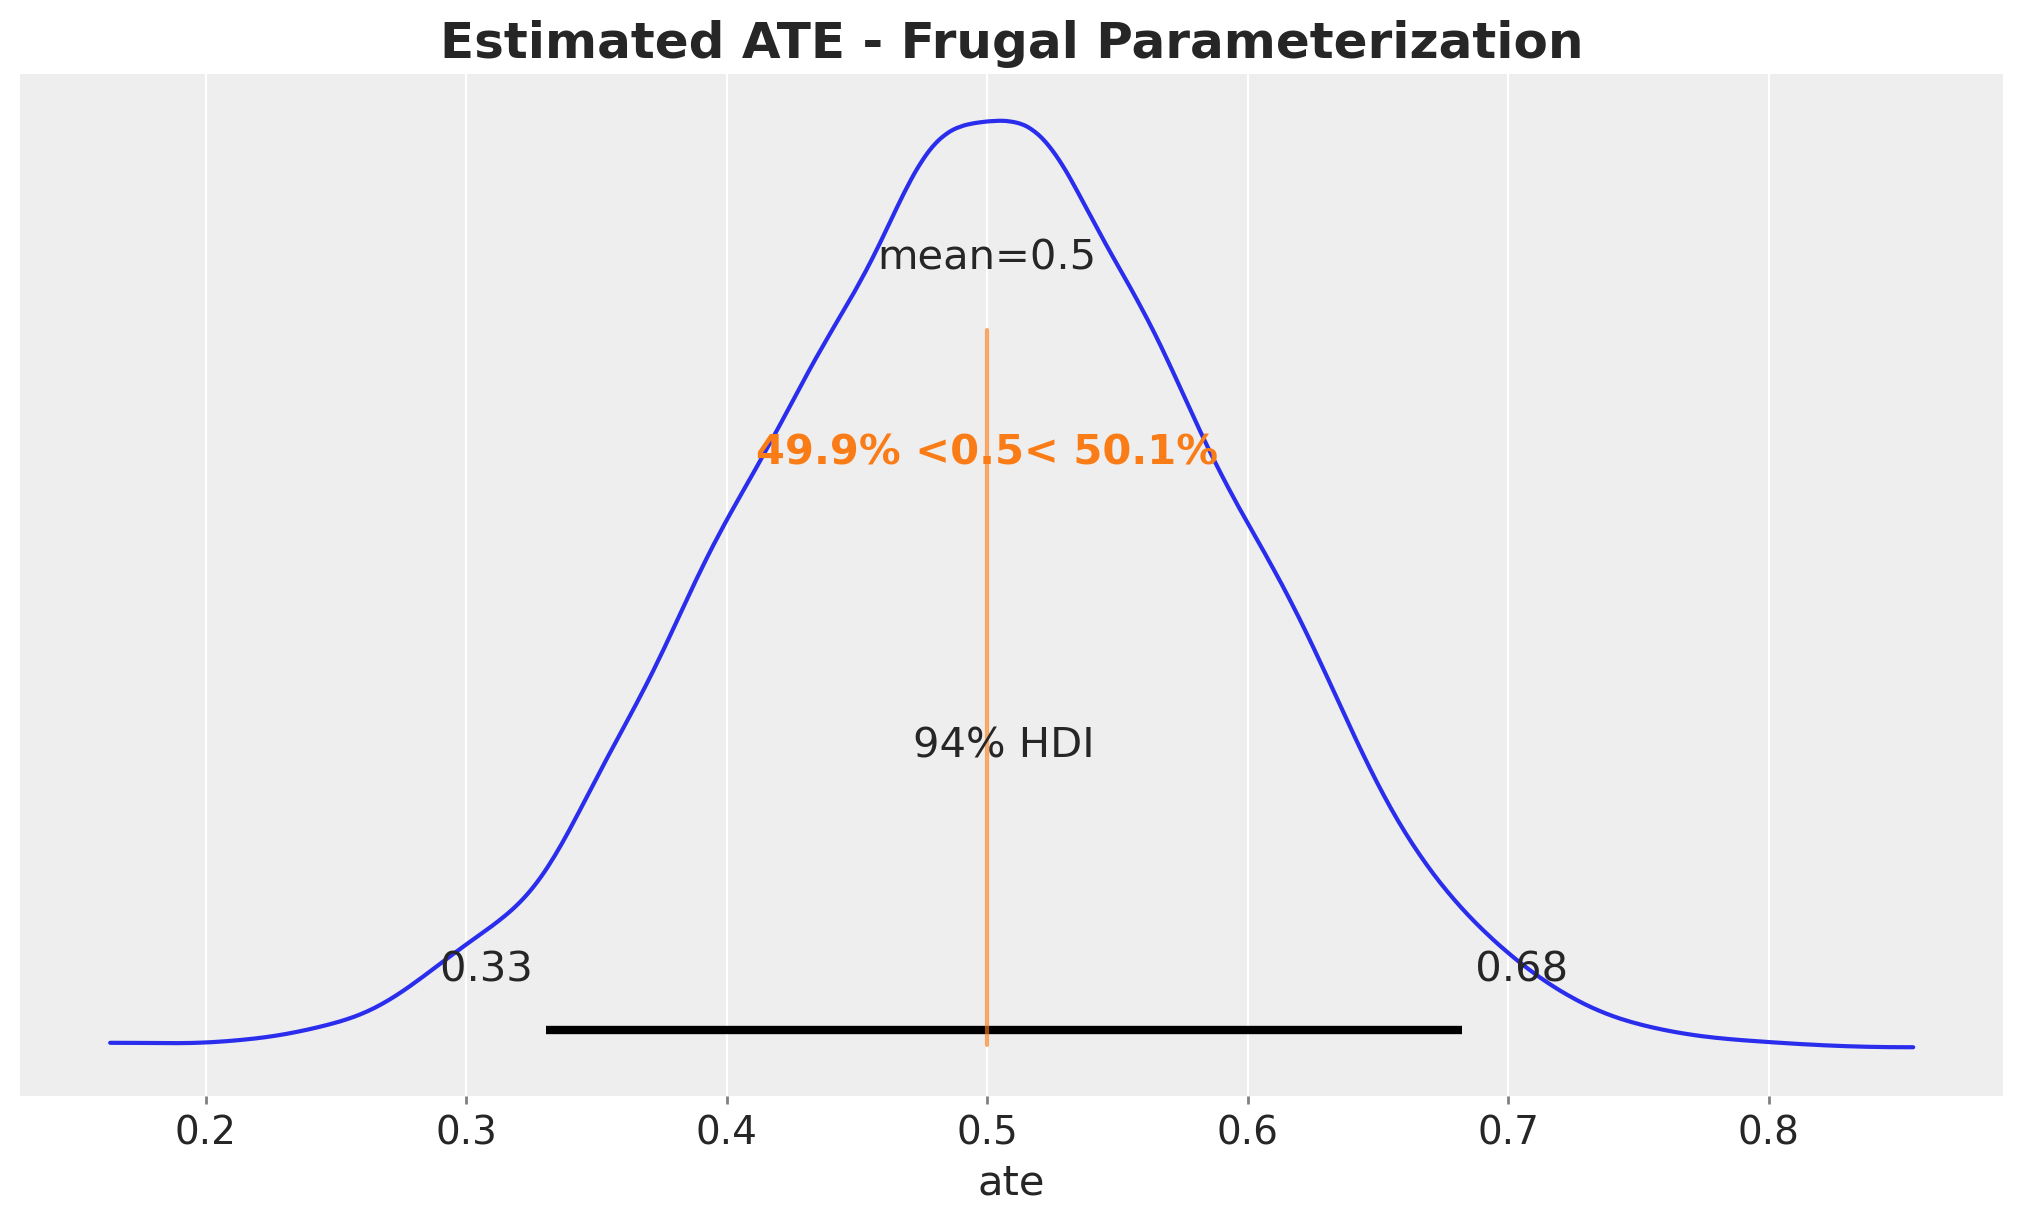

In [16]:
fig, ax = plt.subplots()
az.plot_posterior(idata_frugal, var_names=["delta"], ref_val=sim_params.true_ate, ax=ax)
ax.set(xlabel="ate")
ax.set_title("Estimated ATE - Frugal Parameterization", fontsize=18, fontweight="bold");

It also recovers the true ATE around $0.5$.

## Comparison

In this linear Gaussian case, the two parameterizations should give essentially the same posterior for the ATE. The point is not that frugal is *better* here, but that it opens the door to things you can't easily do with the standard approach.

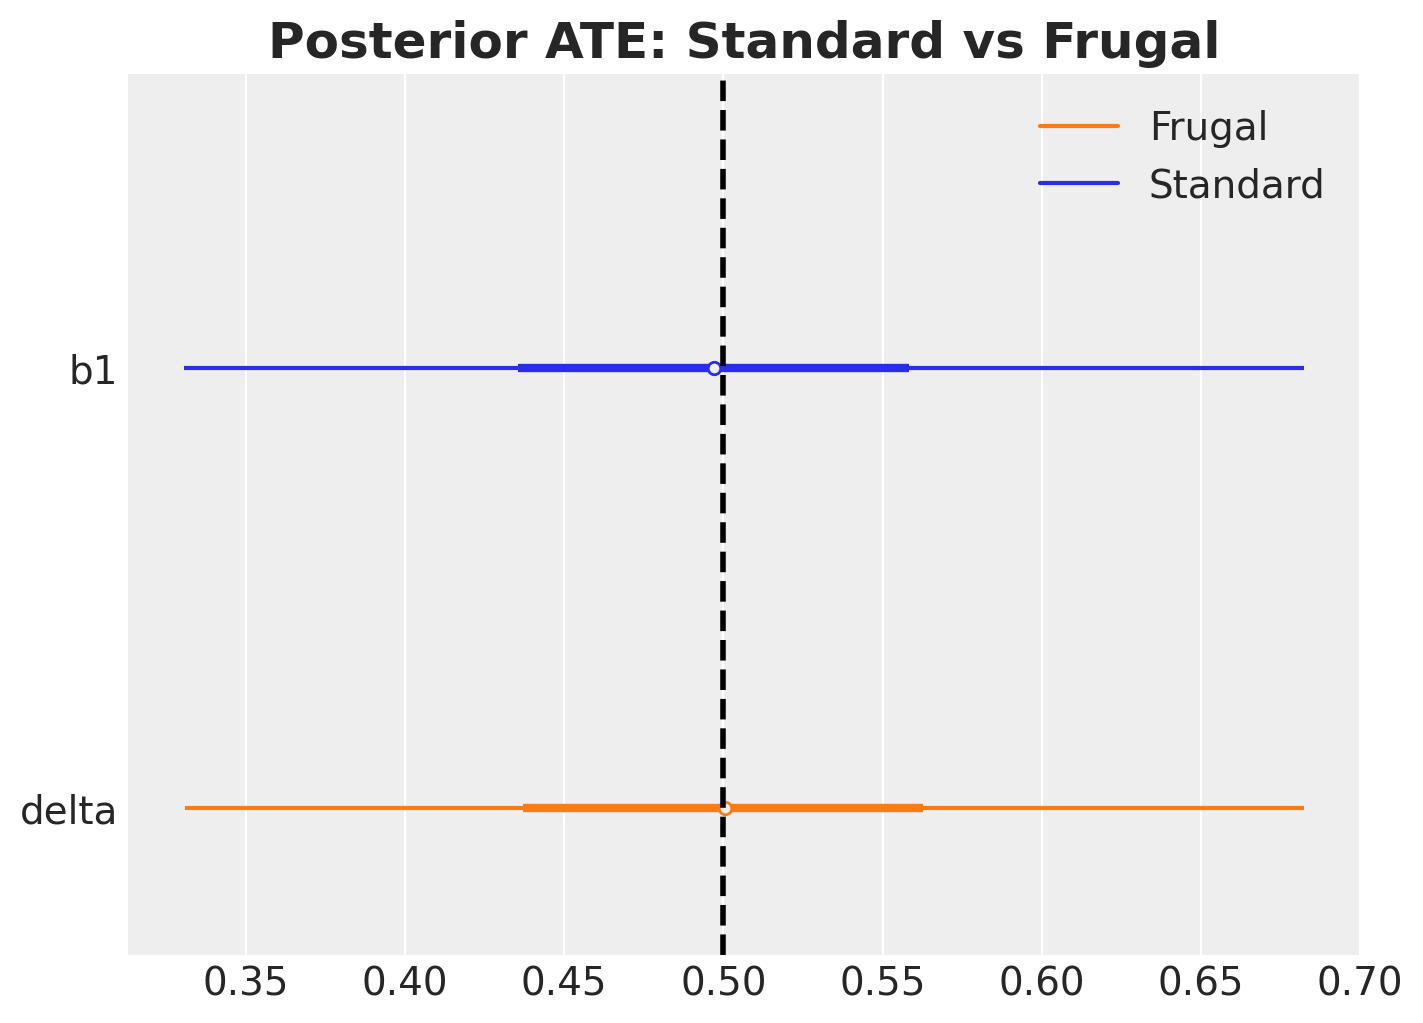

In [17]:
ax, *_ = az.plot_forest(
    [idata_standard, idata_frugal],
    model_names=["Standard", "Frugal"],
    var_names=["b1", "delta"],
    combined=True,
    figsize=(7, 5),
)
ax.axvline(sim_params.true_ate, color="black", linestyle="--", lw=2)
ax.set_title("Posterior ATE: Standard vs Frugal", fontsize=18, fontweight="bold");

They are indeed identical.

## The Payoff: Informative Priors on the Causal Effect

The real advantage of the frugal parameterization becomes clear when you have **prior knowledge about the causal effect itself**, which is extremely common in practice.

### Scenario: combining experimental and observational evidence

Imagine you are a data scientist at a company that has:

1. **A small experiment** (e.g., a geo-lift test, a pilot RCT, an A/B test) that gives a noisy estimate of the causal effect: $\hat{\delta} \approx 0.5 \pm 0.1$.
2. **A large observational dataset** where the treatment was deployed non-randomly and confounding is present.

You want to combine these two sources of information. With the frugal parameterization, this is trivial: put the experimental result as an informative prior on $\delta$.

With the standard parameterization, you would need to translate "$\delta \approx 0.5 \pm 0.1$" into priors on regression coefficients, which is not straightforward, especially if the model is **non-linear**.

Let's compare a weakly informative prior $\delta \sim \text{Normal}(0, 2)$ against an informative prior $\delta \sim \text{Normal}(0.5, 0.1)$ in the frugal model.

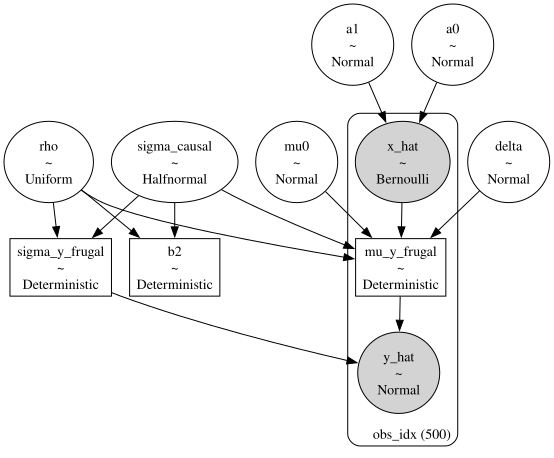

In [18]:
with pm.Model(coords=coords) as frugal_informative:
    # (a) The past
    a0 = pm.Normal("a0", 0, 2)
    a1 = pm.Normal("a1", 0, 2)
    x_hat = pm.Bernoulli(
        "x_hat", p=pm.math.invlogit(a0 + a1 * z_obs), observed=x_obs, dims="obs_idx"
    )

    # (b) Causal margin with INFORMATIVE prior on ATE
    mu0 = pm.Normal("mu0", 0, 2)  # E[Y | do(X=0)]
    delta = pm.Normal("delta", 0.5, 0.1)  # <-- from a pilot experiment
    sigma_causal = pm.HalfNormal("sigma_causal", 1)

    # --- (c) Dependence: Gaussian copula ---
    rho = pm.Uniform("rho", -0.95, 0.95)

    b2 = pm.Deterministic("b2", rho * sigma_causal)

    # --- Observational likelihood ---
    mu_y_frugal = pm.Deterministic(
        "mu_y_frugal", mu0 + delta * x_hat + rho * sigma_causal * z_obs, dims="obs_idx"
    )
    sigma_y_frugal = pm.Deterministic(
        "sigma_y_frugal",
        sigma_causal * pt.sqrt(1 - rho**2),
    )

    pm.Normal(
        "y_hat", mu=mu_y_frugal, sigma=sigma_y_frugal, observed=y_obs, dims="obs_idx"
    )

pm.model_to_graphviz(frugal_informative)

In [19]:
with frugal_informative:
    idata_informative = pm.sample_prior_predictive(draws=1_000, random_seed=rng)
    idata_informative.extend(pm.sample(**sampler_kwargs))

Sampling: [a0, a1, delta, mu0, rho, sigma_causal, x_hat, y_hat]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a0, a1, mu0, delta, sigma_causal, rho]


Output()

Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 1 seconds.


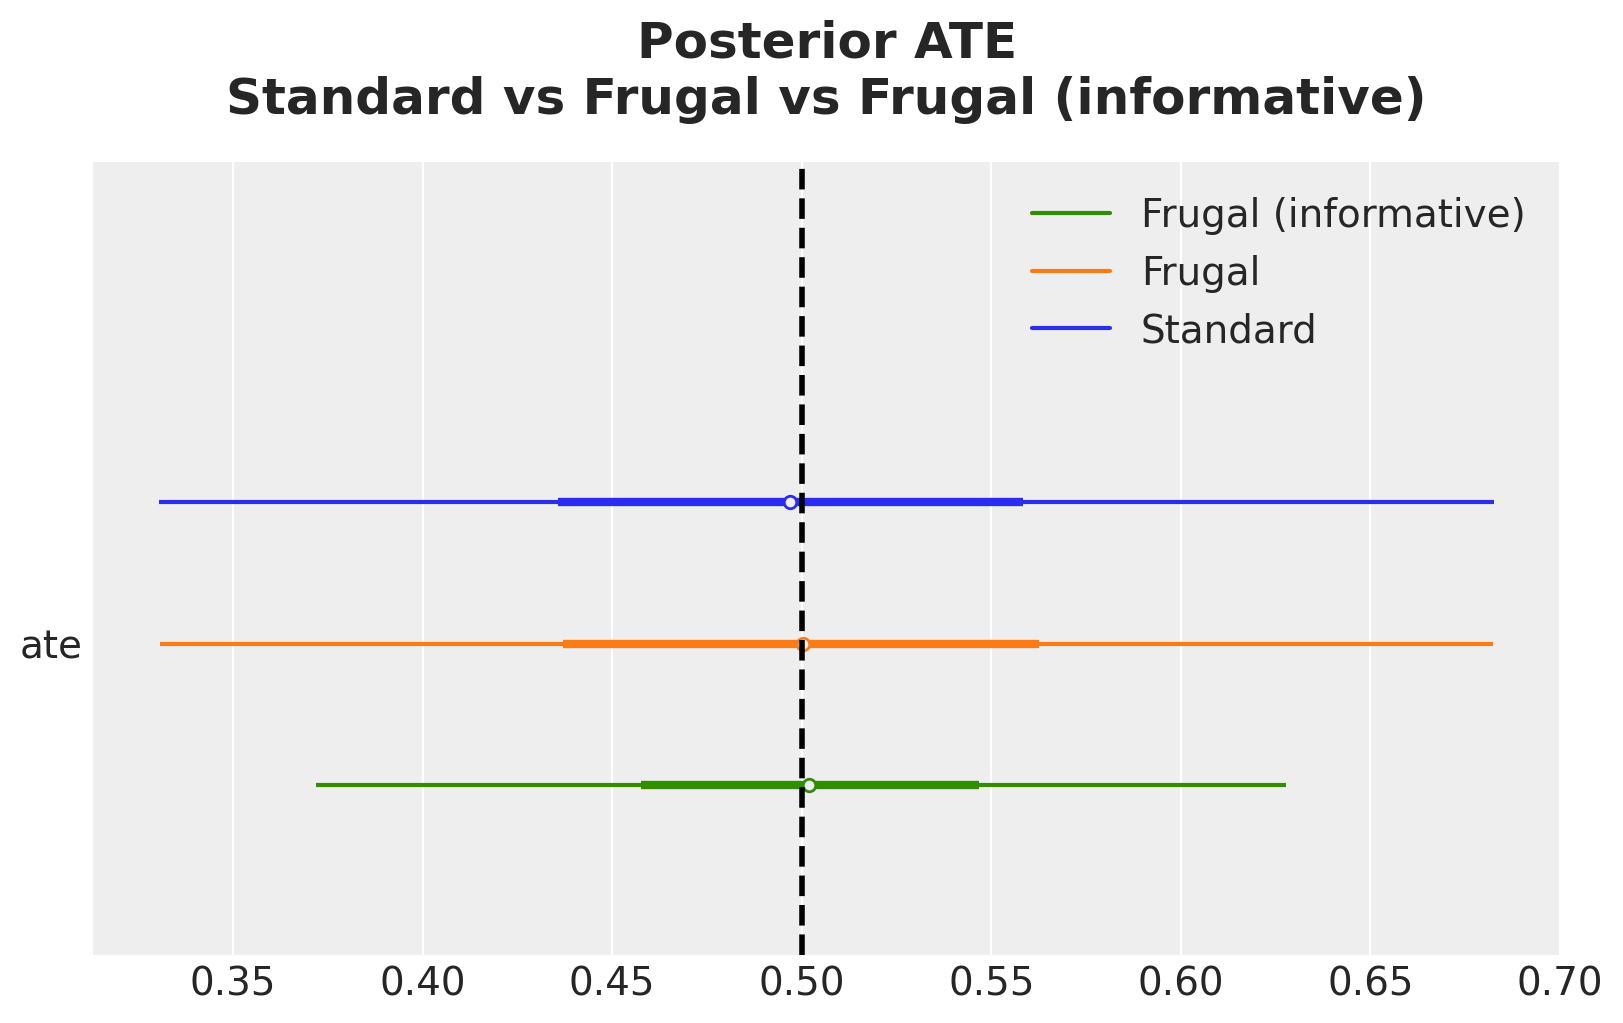

In [20]:
ax, *_ = az.plot_forest(
    [
        idata_standard.rename({"b1": "ate"}),
        idata_frugal.rename({"delta": "ate"}),
        idata_informative.rename({"delta": "ate"}),
    ],
    model_names=["Standard", "Frugal", "Frugal (informative)"],
    var_names=["ate"],
    combined=True,
    figsize=(8, 5),
)
ax.axvline(sim_params.true_ate, color="black", linestyle="--", lw=2)
ax.set_title(
    "Posterior ATE\nStandard vs Frugal vs Frugal (informative)",
    fontsize=18,
    fontweight="bold",
    y=1.05,
);

The informative prior sharpens the posterior by increasing the precision of the posterior estimate. This is the Bayesian machinery doing exactly what it should: combining prior knowledge (from the experiment) with new evidence (from the observational data).



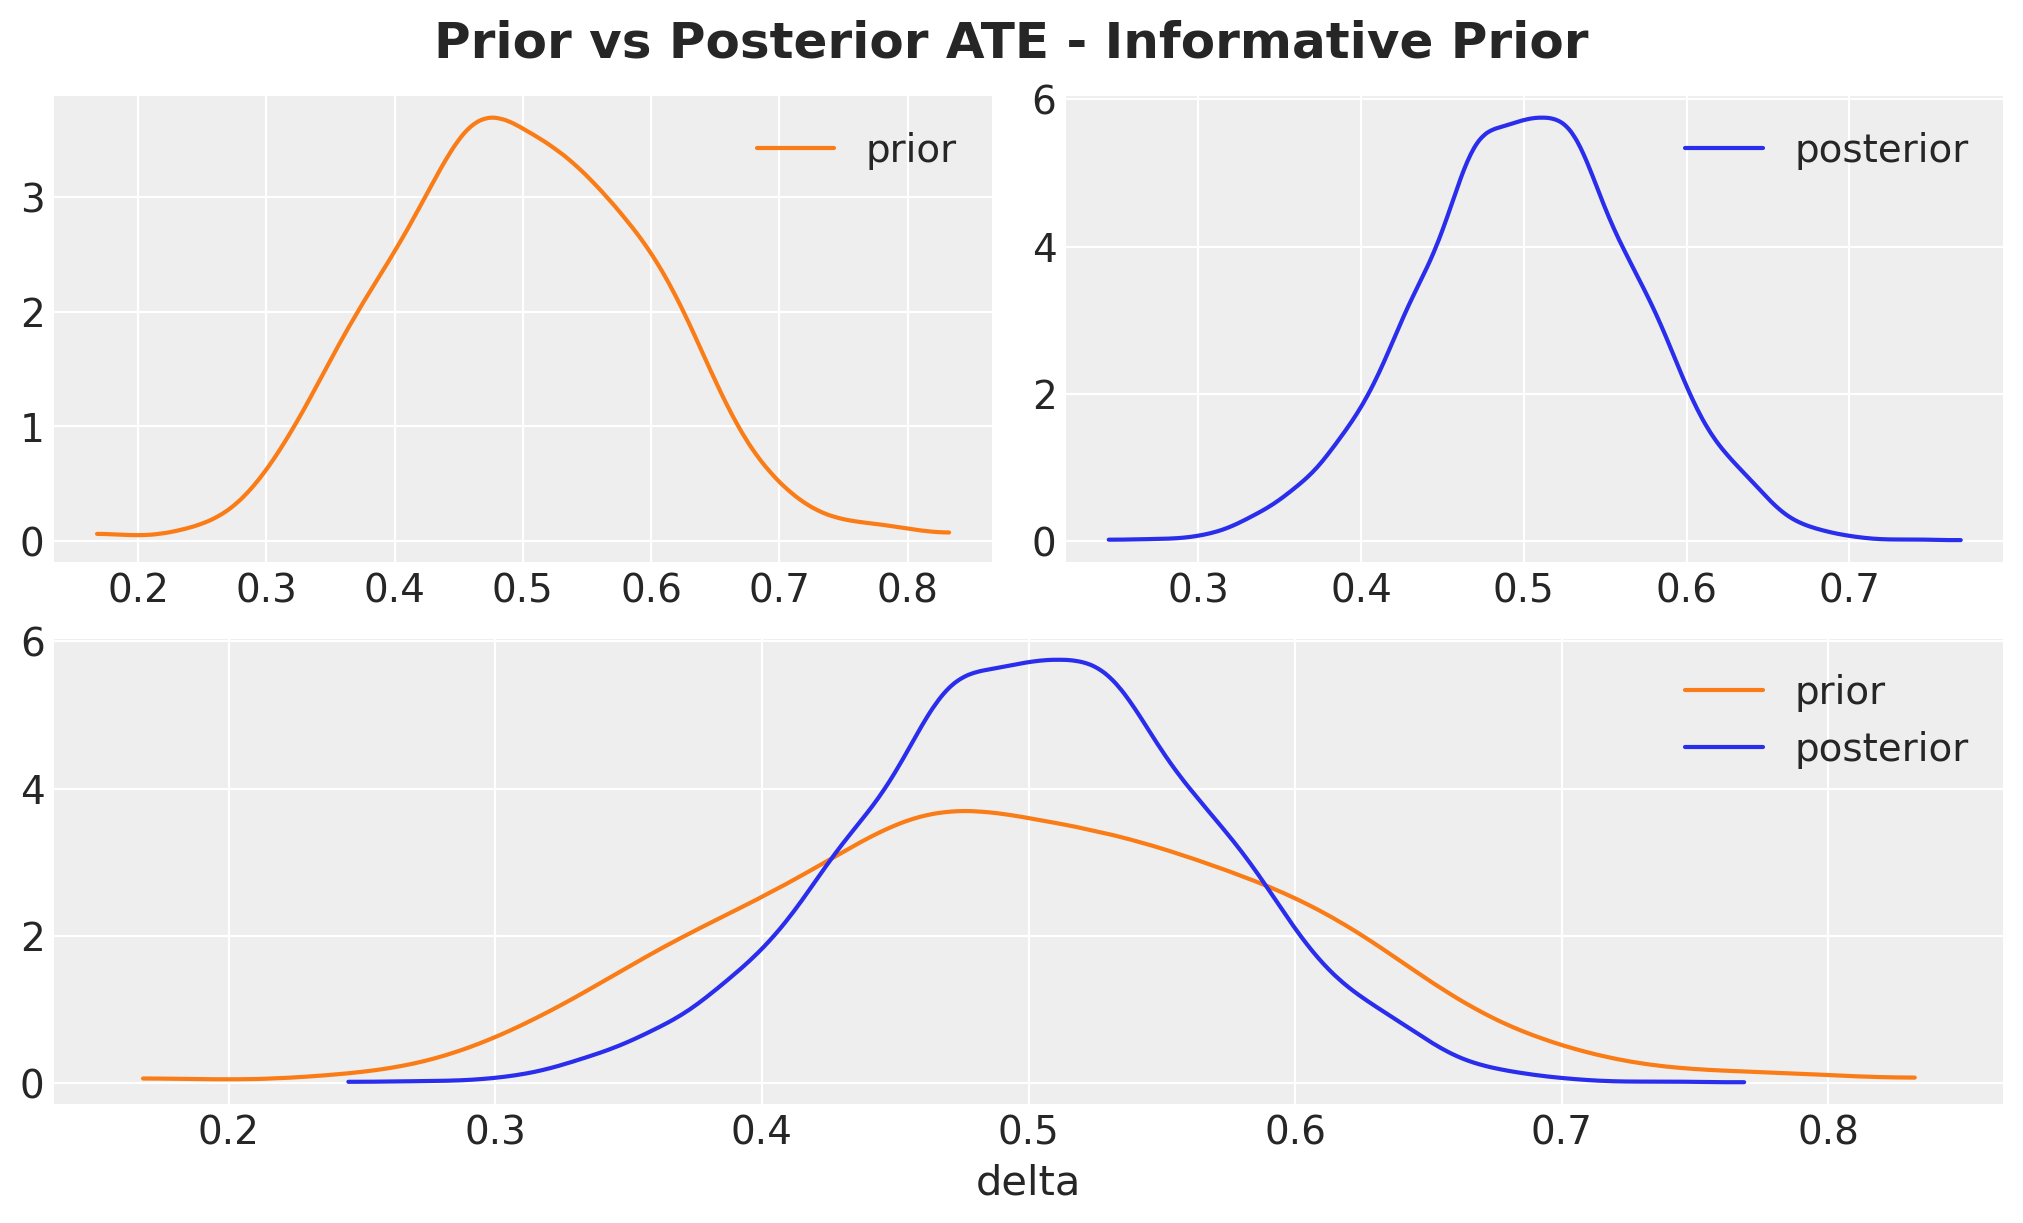

In [21]:
axes = az.plot_dist_comparison(
    data=idata_informative, var_names=["delta"], figsize=(10, 6)
)

fig = plt.gcf()
fig.suptitle(
    "Prior vs Posterior ATE - Informative Prior", fontsize=18, fontweight="bold"
);

Note that the posterior is *not* just the prior, the data genuinely updates it.

## Inspecting the Copula Dependence Parameter

The copula correlation $\rho$ captures the residual association between $Y$ and $Z$ that is not explained by the causal effect of $X$ on $Y$. More precisely, $\rho$ is the Pearson correlation between $Y$ and $Z$ in the *interventional* world (after removing the effect of $X$). Let's plot the posterior of $\rho$:

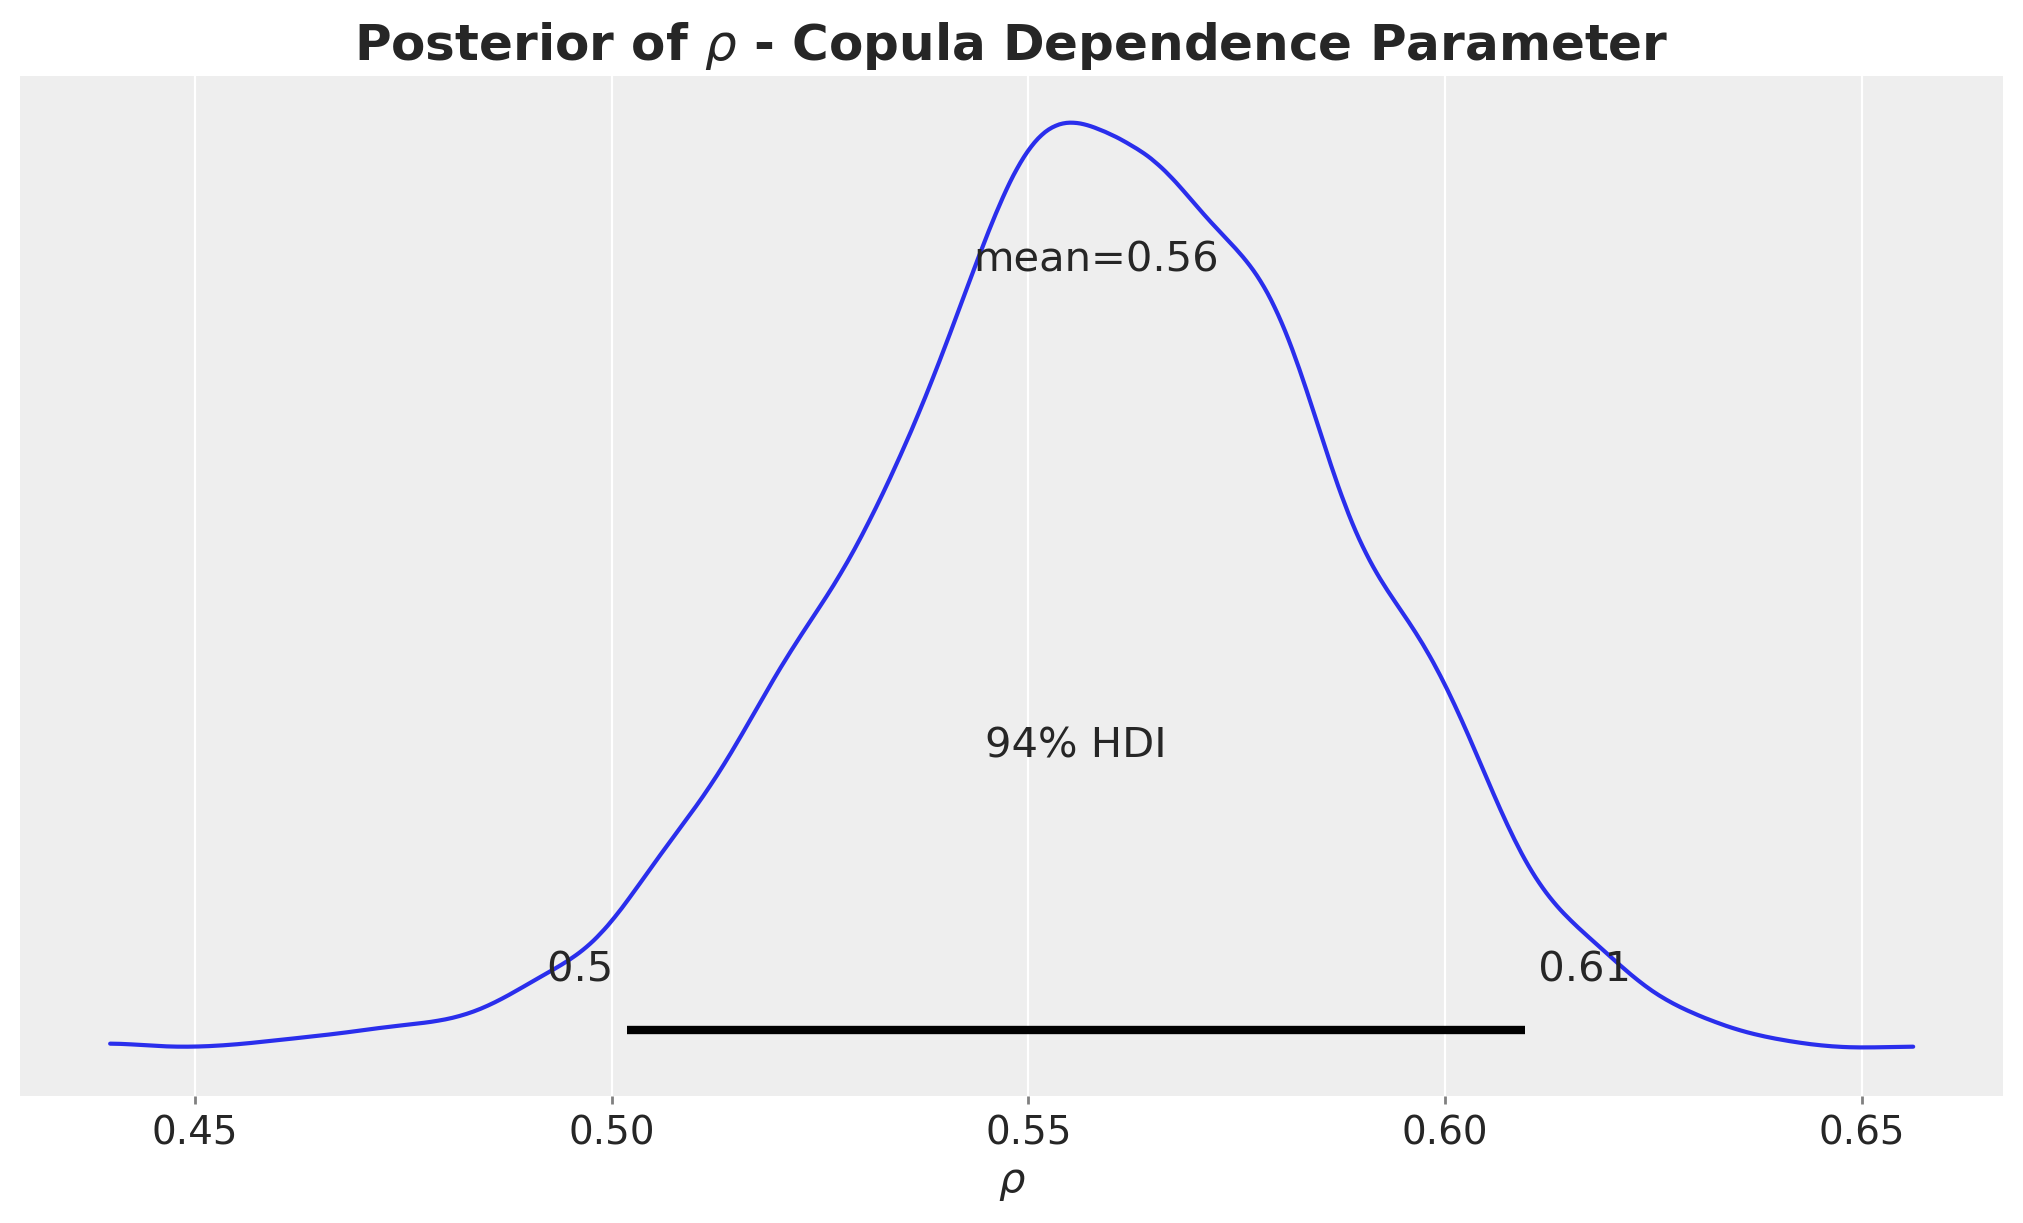

In [22]:
fig, ax = plt.subplots()
az.plot_posterior(idata_frugal, var_names=["rho"], ax=ax)
ax.set(xlabel=r"$\rho$")
ax.set_title(
    r"Posterior of $\rho$ - Copula Dependence Parameter", fontsize=18, fontweight="bold"
);

This posterior does not overlaps zero, meaning that the confounder $Z$ is associated with the outcome $Y$ even after removing the effect of $X$.

In the standard model, this role is played by the regression coefficient $\beta_2$, but $\rho$ and $\beta_2$ encode the same information differently:

- $\beta_2 = \rho \cdot \sigma_c$ gives the *unstandardized* effect of $Z$ on $Y$ (in the units of $Y$ per unit of $Z$).
- $\rho$ gives the *standardized* (correlation-scale) effect, which is unit-free. This makes it easier to set priors on $\rho$ across different datasets and scales.

**Interpreting $\rho$ in practice:**

- $\rho = 0$ means $Z$ has no direct association with $Y$ beyond its effect through $X$. There is no confounding of the $X \to Y$ relationship by $Z$.
- $|\rho|$ close to $1$ means $Z$ almost perfectly predicts $Y$ even after removing $X$'s effect: strong confounding.
- $\rho^2$ gives the fraction of the interventional variance of $Y$ explained by $Z$. For example, $\rho = 0.3$ means the confounder explains about $9\%$ ($= 0.3^2$) of the interventional variance.

Let's verify that the frugal model's implied confounder effect ($\rho \cdot \sigma_c$) is consistent with the standard model's $\beta_2$.

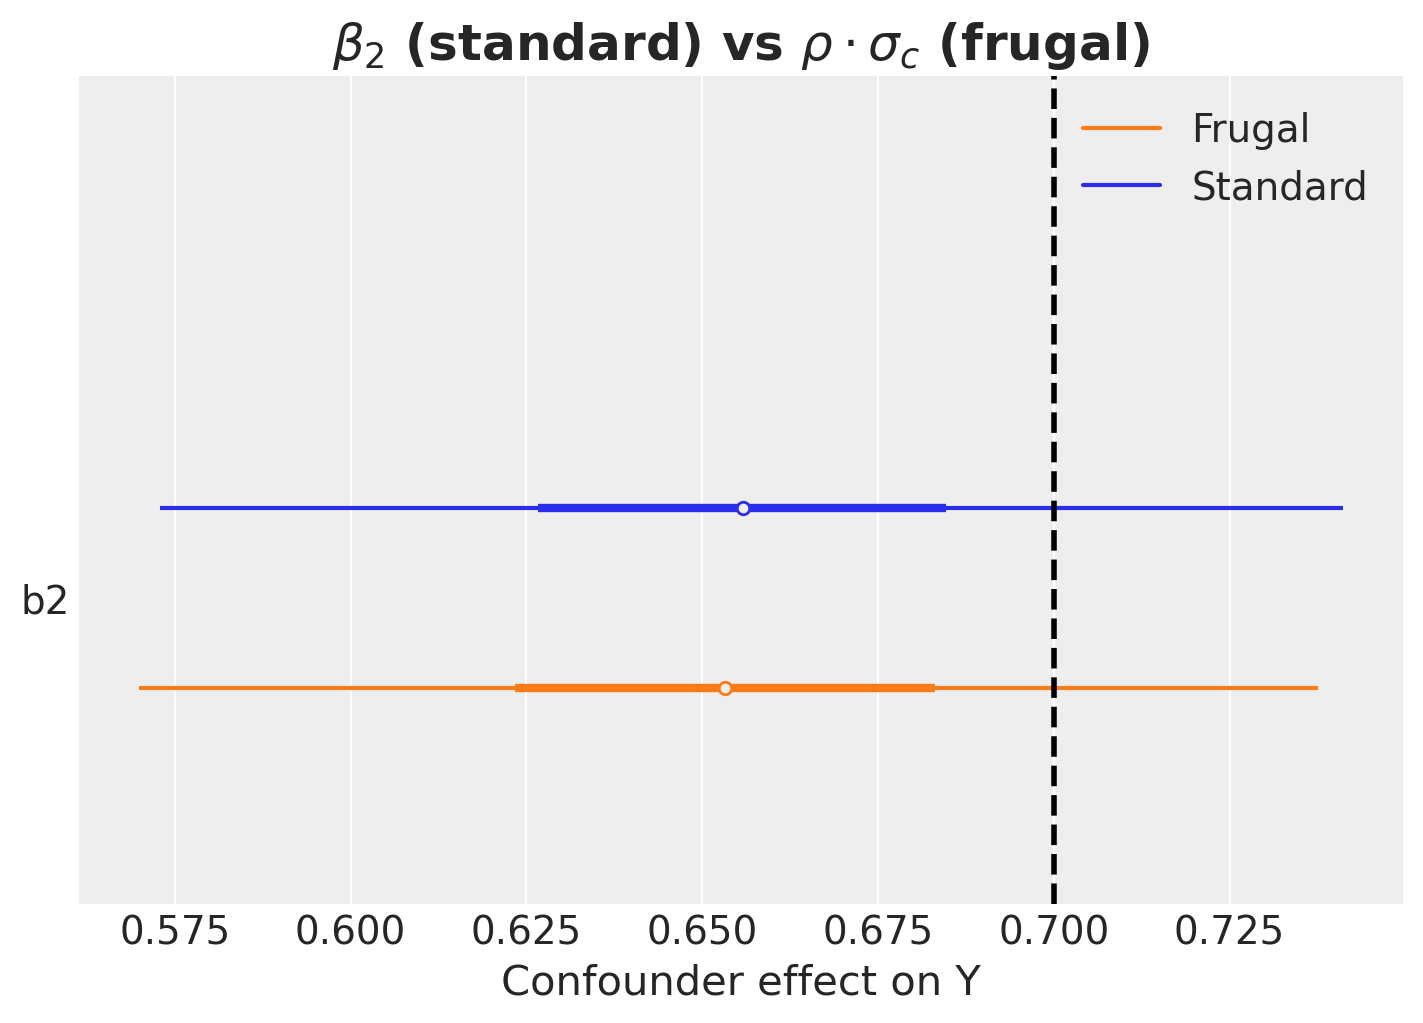

In [23]:
ax, *_ = az.plot_forest(
    [idata_standard, idata_frugal],
    model_names=["Standard", "Frugal"],
    var_names=["b2"],
    combined=True,
    figsize=(7, 5),
)
ax.axvline(
    sim_params.beta_2,
    color="black",
    linestyle="--",
    lw=2,
    label=f"True beta_2 = {sim_params.beta_2}",
)
ax.set(
    xlabel="Confounder effect on Y",
)
ax.set_title(
    r"$\beta_2$ (standard) vs $\rho \cdot \sigma_c$ (frugal)",
    fontsize=18,
    fontweight="bold",
);

The forest plot confirms that the frugal model's implied confounder effect ($\rho \cdot \sigma_c$, stored as the deterministic variable `b2`) matches the standard model's $\beta_2$: they are equivalent reparameterizations in the linear Gaussian case.

## Limitations and Extensions

This notebook covers the **simplest possible case**: continuous Gaussian outcome, binary treatment, a single confounder, and a Gaussian copula. The Evans & Didelez framework is much more general:

- **Discrete outcomes:** Use odds ratios instead of copulas for the dependence component, as discussed in the appendix on odds ratios below. The frugal parameterization works with log-linear models.

- **Non-Gaussian outcomes:** Use different copula families (Clayton, Frank, Gumbel, vine copulas) and/or different marginal distributions, as discussed in the copula primer above (see appendix below).

- **Continuous treatments:** The ATE generalizes to a dose-response curve. The causal margin becomes $P^*(Y \mid \text{do}(X=x))$ for continuous $x$.

- **Multiple confounders:** The copula extends to higher dimensions via vine copulas (pair-copula constructions), as discussed above, though parameterization becomes more complex.

**References:**
- Evans, R.J. & Didelez, V. (2024). *Parameterizing and simulating from causal models.* Journal of the Royal Statistical Society Series B, 86(3), 535–568. [DOI](https://doi.org/10.1093/jrsssb/qkad058)
- Steiner, G. & Steel, M.F.J. (2024). Discussion contribution to Evans & Didelez. JRSS-B, 86(3), 580–582.
- Evans, R.J. (2023). `causl`: R package for specifying, simulating from and fitting causal models. [GitHub](https://github.com/rje42/causl)
- Pearl, J. (2009). *Causality: Models, Reasoning, and Inference.* 2nd ed. Cambridge University Press.
- Havercroft, W.G. & Didelez, V. (2012). Simulating from marginal structural models with time-dependent confounding. *Statistics in Medicine*, 31(30), 4190–4206.
- Sklar, A. (1959). Fonctions de répartition à n dimensions et leurs marges. *Publications de l'Institut Statistique de l'Université de Paris*, 8, 229–231.
- Wiki: https://en.wikipedia.org/wiki/Copula_(statistics)


## Summary

| | Standard | Frugal |
|---|---|---|
| **ATE is...** | a derived quantity | a direct parameter |
| **Priors on ATE** | indirect (via regression coefficients) | direct |
| **Simulation with known ATE** | hard (reverse-engineer conditionals) | easy (set $\delta$) |
| **Dependence structure** | regression coefficients | copula |
| **Variation independence** | not guaranteed | built in |
| **Bayesian prior independence** | not guaranteed | natural |
| **Non-linear models** | ATE is a complex function of parameters | ATE is still $\delta$ |

The frugal parameterization does not give you a *better* answer in the linear
Gaussian case — it gives you a *better language* for expressing your assumptions
and incorporating prior knowledge about causal effects. The payoff grows with
model complexity.

---

## Appendix A: Deriving the observational likelihood

For readers who want to understand *why* the conditional distribution has the form above, here is a step-by-step derivation that makes the construction explicit.

**Step 1: Constructing the interventional joint distribution.**

We have two marginal distributions in the interventional world (where $X$ is set by intervention $\text{do}(X=x)$):

- The interventional outcome: $Y^* \sim \text{Normal}(\mu(x), \, \sigma_c^2)$ where $\mu(x) = \mu_0 + \delta \cdot x$.
- The confounder: $Z \sim \text{Normal}(0, 1)$ (unchanged by the intervention, since $Z$ is a cause of $X$, not a consequence).

These are the marginals. To form a *joint* distribution of $(Y^*, Z)$, we need a dependence structure. This is exactly what the Gaussian copula provides: it couples the two marginals using a single correlation parameter $\rho$. Because both marginals are Gaussian, the Gaussian copula produces a bivariate normal (see the copula primer above):

$$
\begin{pmatrix} Y^* \\ Z \end{pmatrix} \sim
\text{MultivariateNormal}\!\left(
  \begin{pmatrix} \mu(x) \\ 0 \end{pmatrix},
  \begin{pmatrix} \sigma_c^2 & \rho \sigma_c \\ \rho \sigma_c & 1 \end{pmatrix}
\right)
$$

Note that this is a *construction*, not a derivation from data. We are *building* the joint distribution from its three frugal components: the confounder distribution, the interventional outcome margin, and the copula dependence parameter $\rho$.

**Step 2: Conditioning on the confounder.**

From the standard multivariate normal conditioning formula, the conditional distribution of $Y^*$ given $Z = z$ under intervention $\text{do}(X=x)$ is:

$$
Y^* \mid Z=z \;\sim\; \text{Normal}\!\left(
  \mu(x) + \rho \sigma_c \cdot z, \;\; \sigma_c^2(1 - \rho^2)
\right)
$$

The mean shifts by $\rho \sigma_c \cdot z$ (the copula-induced association with the confounder), and the variance shrinks by a factor $(1 - \rho^2)$ (the variance explained by $Z$ is removed).

**Step 3: The identification step:from interventional to observational.**

This is the crucial step that connects the interventional world (where we *set* $X$) to the observational world (where $X$ is determined by the confounder $Z$ through the propensity model).

The **back-door criterion** (Pearl, 2009) states: if $Z$ blocks all back-door paths from $X$ to $Y$ (i.e., there is no unmeasured confounding conditional on $Z$), then the interventional distribution of $Y$ under $\text{do}(X=x)$ is identified from observational data via:

$$
P(Y \mid \text{do}(X=x)) = \int P(Y \mid X=x, Z=z) \, P(Z=z) \, dz
$$

A key consequence of this identification result is that the *conditional* distributions also match:

$$
P(Y \mid X=x, Z=z) = P(Y^* \mid Z=z) \quad \text{under } \text{do}(X=x)
$$

In words: once we condition on the confounder $Z$, the observational conditional of $Y$ given $X$ and $Z$ equals the interventional conditional of $Y^*$ given $Z$. This is because conditioning on $Z$ "blocks" the confounding path $Y \leftarrow Z \rightarrow X$, making the remaining variation in $X$ as-good-as-random.

**Remark: cognate distributions.** Evans & Didelez (2024) generalize this identification step through the concept of *cognate distributions*: conditional distributions of the form 

$$P^*_{Y \mid X}(y \mid x) = \int P_{Y \mid ZX}(y \mid z, x) \, w(z \mid x) \, dz$$

for different weight functions $w$. The back-door adjustment above uses $w(z \mid x) = P(Z = z)$ (the marginal of $Z$), but other weight functions yield other causal estimands, for example, $w(z \mid x) = P(Z = z \mid X = 1)$ gives the effect of treatment on the treated. Theorem 3.1 in the paper shows that if a parameterization is frugal with respect to one weight function, it is frugal with respect to any other (under mild regularity conditions), so the framework extends seamlessly to these different causal quantities.

Therefore, the distribution derived in Step 2 is exactly the **observational likelihood** we need for Bayesian inference:

$$
Y \mid X=x, Z=z \;\sim\; \text{Normal}\!\left(
  (\mu_0 + \delta \cdot x) + \rho \sigma_c \cdot z, \;\;
  \sigma_c^2 (1 - \rho^2)
\right)
$$

**Step 4: The role of the propensity score.**

Notice that the propensity model $P(X \mid Z)$ does not appear in the outcome likelihood above, it enters the model separately through the Bernoulli distribution for $X$. This is not a coincidence: it is a direct consequence of the variation independence of the frugal components. The propensity parameters $(\alpha_0, \alpha_1)$ and the causal/dependence parameters $(\delta, \sigma_c, \rho)$ live in separate, non-overlapping parts of the model, so we can specify priors on them independently.

**Step 5: Connection to the standard parameterization.**

We can now make the equivalence between the two parameterizations explicit. Matching coefficients between the frugal likelihood $Y \mid X, Z \sim \text{Normal}((\mu_0 + \delta x) + \rho \sigma_c z, \; \sigma_c^2(1 - \rho^2))$ and the standard regression $Y \mid X, Z \sim \text{Normal}(\beta_0 + \beta_1 x + \beta_2 z, \; \sigma^2)$:

*Forward mapping* (frugal $\to$ standard):

$$
\beta_0 = \mu_0, \quad \beta_1 = \delta, \quad \beta_2 = \rho \sigma_c, \quad \sigma = \sigma_c \sqrt{1 - \rho^2}
$$

*Inverse mapping* (standard $\to$ frugal):

$$
\delta = \beta_1, \quad \sigma_c = \sqrt{\sigma^2 + \beta_2^2}, \quad \rho = \frac{\beta_2}{\sqrt{\sigma^2 + \beta_2^2}}
$$

The inverse mapping reveals an important insight: the causal standard deviation $\sigma_c = \sqrt{\sigma^2 + \beta_2^2}$ is always *larger* than the residual standard deviation $\sigma$ (unless $\beta_2 = 0$, i.e., no confounding). This makes intuitive sense: the causal variance includes the variability that is *absorbed by the confounder* in the standard regression. When we intervene and set $X$, we remove the confounder's ability to "explain away" variance, so the outcome is noisier under intervention than it appears in the observational conditional.



## Appendix B : Extensions

### Beyond the Gaussian copula: other copula families

The Gaussian copula is the simplest choice, but it imposes a specific dependence structure: symmetric and with no *tail dependence* (extreme values of $Y$ and $Z$ are not more strongly associated than moderate values). Other copula families capture different patterns:

| Copula | Dependence structure | Parameter | When to use |
|--------|---------------------|-----------|-------------|
| **Gaussian** | Symmetric, no tail dependence | $\rho \in (-1, 1)$ | Default for continuous outcomes; closed-form with Gaussian margins |
| **Clayton** | Lower-tail dependence | $\theta > 0$ | When confounding is strongest among low-outcome individuals (e.g., sicker patients more likely to receive treatment *and* have worse outcomes) |
| **Frank** | Symmetric, no tail dependence | $\theta \neq 0$ | Similar to Gaussian but works naturally with non-Gaussian margins; a good default when you have no reason to expect tail dependence |
| **Gumbel** | Upper-tail dependence | $\theta \geq 1$ | When confounding is strongest among high-outcome individuals |

The Clayton, Frank, and Gumbel copulas belong to the family of **Archimedean copulas**, which are defined by a generator function $\psi$:

$$
C(u, v) = \psi^{-1}\!\left(\psi(u) + \psi(v)\right)
$$

For example, the Clayton generator is $\psi(t) = (t^{-\theta} - 1)/\theta$, the Frank generator is $\psi(t) = -\log\!\left(\frac{e^{-\theta t} - 1}{e^{-\theta} - 1}\right)$, and the Gumbel generator is $\psi(t) = (-\log t)^\theta$. Each generator induces a different tail behavior, which translates to different assumptions about how confounding operates at the extremes of the outcome distribution.

**Vine copulas for multiple confounders.** When there are multiple confounders $Z_1, Z_2, \ldots, Z_p$, the dependence between $Y$ and all confounders cannot be captured by a single bivariate copula. Vine copulas (also called pair-copula constructions) decompose the multivariate dependence into a cascade of bivariate copulas arranged in a tree structure, where each edge represents a conditional bivariate copula. This is the natural extension of the frugal parameterization to high-dimensional settings, though the parameterization becomes more complex.

**Practical guidance for sensitivity analysis.** In the frugal framework, the choice of copula family affects the dependence component (c) *only*. The causal margin (b) and the past (a) are unchanged. This means you can do sensitivity analysis over copula families: fit the model with Gaussian, Clayton, and Frank copulas and check whether the ATE posterior changes materially. If it does not, your causal conclusions are robust to the dependence specification. If it does, the data alone cannot distinguish between different confounding patterns, and substantive knowledge about the nature of confounding becomes important.

For implementation of copulas in PyMC, see the [PyMC copula estimation example](https://www.pymc.io/projects/examples/en/latest/howto/copula-estimation.html).

#### The discrete outcome case: odds ratios instead of copulas

When the outcome $Y$ is discrete (binary or categorical), the Gaussian copula is no longer the natural choice for the dependence component. The probability integral transform $u = F_Y(y)$ is problematic for discrete variables because the CDF has jumps, making the copula construction ill-defined without additional conventions. Instead, Evans & Didelez (2024) use **conditional odds ratios** as the association measure $\varphi_{YZ \mid X}$.

**The key property** (Proposition 2.2 in Evans & Didelez, 2024) is that the conditional odds ratio is *invariant to reweighting*:

$$
\varphi_{YZ \mid X}(x) = \varphi^*_{YZ \mid X}(x)
$$

This means the odds ratio between $Y$ and $Z$ given $X$ is the *same* whether computed under the observational distribution or under intervention $\text{do}(X=x)$. This invariance is a special property of odds ratios that copulas do not share: while copulas *do* provide a valid frugal parameterization satisfying variation independence (Proposition 2.5), the copula *function itself* is not invariant to reweighting because it depends on the marginal CDFs, which differ between the observational and interventional distributions. In other words, the same numerical value of $\rho$ in a Gaussian copula represents a different dependence structure depending on which marginals it is paired with. This is a subtlety of the copula approach, not a limitation, it simply means that the copula parameter must be interpreted relative to the specified marginals. Odds ratios, by contrast, are self-contained: their numerical value has the same meaning regardless of the marginal distributions.

**Concrete example: binary $Y$ and binary $Z$.** The conditional odds ratio given $X=x$ is:

$$
\varphi(x) = \frac{P(Y=1 \mid Z=1, X=x) \cdot P(Y=0 \mid Z=0, X=x)}{P(Y=0 \mid Z=1, X=x) \cdot P(Y=1 \mid Z=0, X=x)}
$$

The frugal parameterization then specifies three independent components: (i) $P(Z, X)$ as before (confounder distribution + propensity score), (ii) $P^*(Y=1 \mid \text{do}(X=x))$ = the causal risk under intervention (a direct parameter for the causal effect), and (iii) $\varphi(x)$ = the odds ratio capturing confounding. The observational conditional $P(Y \mid X, Z)$ is then reconstructed from these three components.

**Connection to log-linear models.** The odds ratio parameterization corresponds to a log-linear model for the conditional distribution of $Y$ given $Z$ and $X$, where the interaction term between $Y$ and $Z$ (given $X$) is the log odds ratio $\log \varphi(x)$. This is the natural parameterization for categorical data, paralleling how the copula is natural for continuous data. Odds ratios also have a long history in epidemiology and social science, making them immediately interpretable to practitioners in those fields.